In [1]:
import pandas as pd
import pickle
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier

In [2]:
os.makedirs('../models', exist_ok=True)
# Lista de tus datasets
# incluir adolescentes
datasets = ['adults', 'combined', 'toddlers']

data_dict = {}

for name in datasets:
    # Cargar datos
    X_train = pd.read_csv(f'../data/processed/{name}_train.csv')
    X_test = pd.read_csv(f'../data/processed/{name}_test.csv')
    
    # Si tus archivos train/test ya contienen la variable target, 
    # recuerda separarla (ej: y_train = X_train.pop('target_column'))
    
    data_dict[name] = {'train': X_train, 'test': X_test}

In [3]:
RANDOM_STATE = 42
MODEL_SPACE = {
    "Baseline": {
        "estimator": DummyClassifier(strategy="most_frequent"),
        "param_grid": {}
    },
    "Regresion Logistica": {
        "estimator": LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "C": [0.01, 0.1, 1, 10],
            #"penalty": ["l2"]
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    "XGBoost": {
        "estimator": XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            # XGBoost no tiene class_weight; se usa scale_pos_weight para
            # compensar el desbalance. Se calcula por dataset mas abajo.
        }
    }
}


In [4]:
# ===========================
# Validación cruzada
# ===========================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

all_results = []

# ===========================
# Entrenamiento
# ===========================

for name, data in data_dict.items():

    print(f"\n{'='*60}")
    print(f"DATASET: {name}")
    print(f"{'='*60}")

    # Copias para no modificar los originales
    train_df = data["train"].copy()
    test_df = data["test"].copy()

    # Separar variables y target
    y_train = train_df.pop("target").astype(int)
    y_test = test_df.pop("target").astype(int)

    X_train = train_df
    X_test = test_df

    # Calcular ratio de desbalance (solo para XGBoost)
    n_pos = (y_train == 1).sum()
    n_neg = (y_train == 0).sum()
    ratio = n_neg / n_pos if n_pos > 0 else 1

    # ====================================
    # Entrenar todos los modelos
    # ====================================

    for model_name, config in MODEL_SPACE.items():

        print(f"\n----- {model_name} -----")

        clf = config["estimator"]
        params = config["param_grid"]

        # Ajuste específico para XGBoost
        if model_name == "XGBoost":
            clf.set_params(scale_pos_weight=ratio)

        # Grid Search
        grid = GridSearchCV(
            estimator=clf,
            param_grid=params,
            cv=cv,
            scoring="recall",
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        # Mejor modelo
        best_model = grid.best_estimator_

        # Predicción
        y_pred = best_model.predict(X_test)

        # Métricas
        report = classification_report(
            y_test,
            y_pred,
            output_dict=True,
            zero_division=0
        )

        print(f"Mejor escore: {grid.best_score_:.4f}")
        print(f"Mejores parámetros: {grid.best_params_}\n")

        print(classification_report(
            y_test,
            y_pred,
            zero_division=0
        ))

        print("Matriz de confusión:")
        print(confusion_matrix(y_test, y_pred))

        # Guardar resultados
        all_results.append({

            "Dataset": name,
            "Modelo": model_name,

            "F1 CV": round(grid.best_score_, 4),

            "Accuracy": report["accuracy"],

            "Precision (TEA)": report["1"]["precision"],
            "Recall (TEA)": report["1"]["recall"],
            "F1-Score (TEA)": report["1"]["f1-score"],
            "Support (TEA)": report["1"]["support"],

            "Best Params": str(grid.best_params_)
        })

        # Guardar modelo
        model_filename = f"../models/{name}_{model_name}.pkl"

        with open(model_filename, "wb") as f:
            pickle.dump(best_model, f)

        print(f"Modelo guardado en: {model_filename}")

print("\nEntrenamiento finalizado.")


DATASET: adults

----- Baseline -----


Mejor escore: 0.0000
Mejores parámetros: {}

              precision    recall  f1-score   support

           0       0.73      1.00      0.84       103
           1       0.00      0.00      0.00        38

    accuracy                           0.73       141
   macro avg       0.37      0.50      0.42       141
weighted avg       0.53      0.73      0.62       141

Matriz de confusión:
[[103   0]
 [ 38   0]]
Modelo guardado en: ../models/adults_Baseline.pkl

----- Regresion Logistica -----
Mejor escore: 0.9933
Mejores parámetros: {'C': 1}

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       103
           1       0.97      0.97      0.97        38

    accuracy                           0.99       141
   macro avg       0.98      0.98      0.98       141
weighted avg       0.99      0.99      0.99       141

Matriz de confusión:
[[102   1]
 [  1  37]]
Modelo guardado en: ../models/adults_Regresion Logistica.pkl

----- Random Fore

In [5]:
results_df = (
    pd.DataFrame(all_results)
    .sort_values(
        by=["Dataset", "Recall (TEA)"],
        ascending=[True, False]
    )
)

display(results_df)

,Dataset,Modelo,F1 CV,Accuracy,Precision (TEA),Recall (TEA),F1-Score (TEA),Support (TEA),Best Params
1,adults,Regresion Logistica,0.9933,0.985816,0.973684,0.973684,0.973684,38.0,{'C': 1}
3,adults,XGBoost,0.9604,0.992908,1.000000,0.973684,0.986667,38.0,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti..."
2,adults,Random Forest,0.9602,0.936170,0.871795,0.894737,0.883117,38.0,"{'max_depth': 5, 'min_samples_leaf': 4, 'n_est..."
0,adults,Baseline,0.0000,0.730496,0.000000,0.000000,0.000000,38.0,{}
7,combined,XGBoost,1.0000,0.994239,0.980978,1.000000,0.990398,361.0,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
5,combined,Regresion Logistica,0.9792,0.906996,0.774336,0.969529,0.861009,361.0,{'C': 0.01}
6,combined,Random Forest,0.9792,0.933333,0.833333,0.969529,0.896287,361.0,"{'max_depth': 5, 'min_samples_leaf': 1, 'n_est..."
4,combined,Baseline,0.0000,0.702881,0.000000,0.000000,0.000000,361.0,{}
8,toddlers,Baseline,1.0000,0.691943,0.691943,1.000000,0.817927,146.0,{}
9,toddlers,Regresion Logistica,1.0000,1.000000,1.000000,1.000000,1.000000,146.0,{'C': 10}


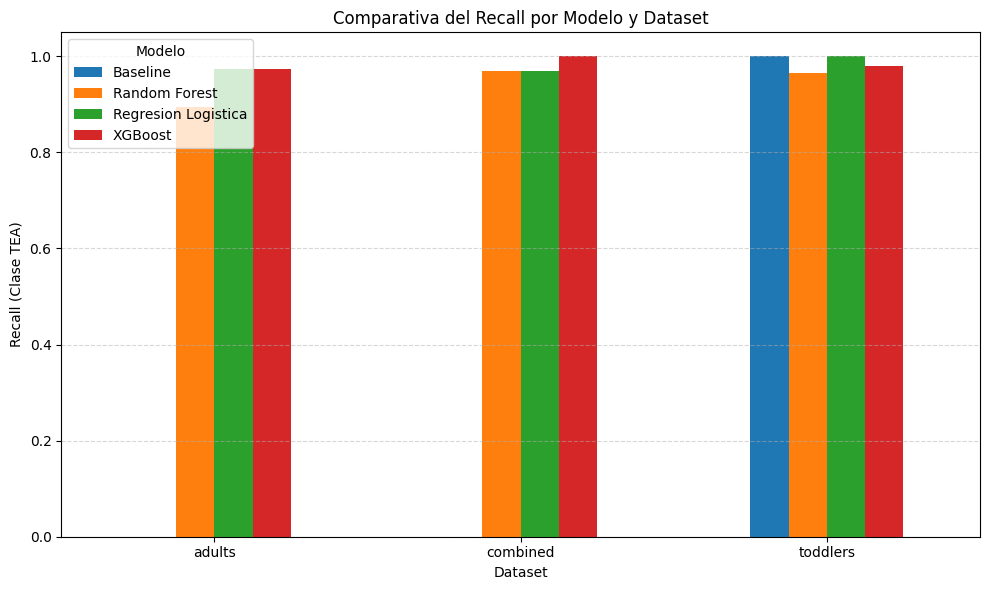

In [6]:
results_df.pivot(
    index="Dataset",
    columns="Modelo",
    values="Recall (TEA)"
).plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparativa del Recall por Modelo y Dataset")
plt.ylabel("Recall (Clase TEA)")
plt.xlabel("Dataset")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
# Cargar el modelo guardado con pickle
model_path = '../models/adults_XGBoost.pkl'
with open(model_path, 'rb') as f:
    modelo_cargado = pickle.load(f)

# 1. Obtenemos el DataFrame de test
df_test = data_dict["adults"]["test"].copy()

# 2. Eliminamos el target para que coincida con las columnas del entrenamiento
if 'target' in df_test.columns:
    df_test = df_test.drop(columns=['target'])

# 3. Ahora sí, hacemos la predicción
# Si el error persiste, significa que necesitas el preprocesador para 
# ajustar las variables a las 99 esperadas.
prediccion = modelo_cargado.predict(df_test.iloc[0:1])

# Suponiendo que ya tienes la predicción (del paso anterior)
valor_real = data_dict["adults"]["test"].iloc[0:1]["target"].values[0]

print(f"Predicción del modelo: {prediccion[0]}")
print(f"Valor real (etiqueta): {valor_real}")

if prediccion[0] == valor_real:
    print("¡El modelo ha acertado!")
else:
    print("El modelo ha fallado en esta instancia.")


Predicción del modelo: 0
Valor real (etiqueta): 0
¡El modelo ha acertado!
